# Notebook 04: Clustering

## Objective
Identify latent population segments based on health and lifestyle features using unsupervised learning.

## Scope
- Select clustering features and scale them
- Dimensionality reduction with PCA (retain ~85% variance)
- Assess cluster tendency (Hopkins)
- Choose k via elbow and silhouette
- Fit K-Means on full data and Agglomerative on a sample
- Interpret clusters with feature summaries and diabetes prevalence cross-tabs

## Clustering Strategy
- **Preprocessing:** StandardScaler to equalize feature scales, then PCA to reduce correlation and noise.
- **K-Means:** Primary algorithm for scalability; evaluated with silhouette on a sample.
- **Agglomerative (Ward):** Applied to a subsample for robustness comparison.

## Evaluation
- Internal validation with silhouette and cluster sizes; visual inspection in PCA space.
- Robustness check via agreement between K-Means and Agglomerative on the shared sample.

## Output
- Cluster assignments, plots, and interpretive summaries for downstream reporting.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

In [ ]:
# Data path and load
DATA_PATH = Path('../')/"data"/"raw_data"/"CDC_Diabetes_Dataset.csv"
# Loading Raw Data
df = pd.read_csv(DATA_PATH)

In [ ]:
# CELL 1 — Imports + Config


RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Features used for clustering
CLUSTER_COLS = [
    "Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
    "CholCheck", "AnyHealthcare", "NoDocbcCost",
    "BMI", "HighBP", "HighChol", "Age", "Sex", "Education", "Income"
]

TARGET_COL = "Diabetes_012"  # only for interpretation (optional)

In [5]:
# CELL 2 — Preprocess: extract X, scale, PCA (retain 85% variance)
# Validate clustering columns
missing = [c for c in CLUSTER_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

# Keep only rows with complete clustering features
df2 = df.dropna(subset=CLUSTER_COLS).copy()

# Use float32 to reduce RAM usage
X = df2[CLUSTER_COLS].astype(np.float32).to_numpy()

# Scale features to zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

# PCA to retain ~85% variance (use full/auto solver; 15 features is cheap)
pca = PCA(n_components=0.85, random_state=RANDOM_STATE, svd_solver="full")
X_pca = pca.fit_transform(X_scaled).astype(np.float32)

# Quick summary of preprocessing output
print("Rows used:", X_pca.shape[0])
print("Original features:", X.shape[1])
print("PCA components kept:", X_pca.shape[1])
print("Explained variance (sum):", float(pca.explained_variance_ratio_.sum()))

Rows used: 253680
Original features: 15
PCA components kept: 12
Explained variance (sum): 0.8824087381362915


Hopkins statistic (PCA space): 0.971  (≈0.5 weak, >0.7 strong)


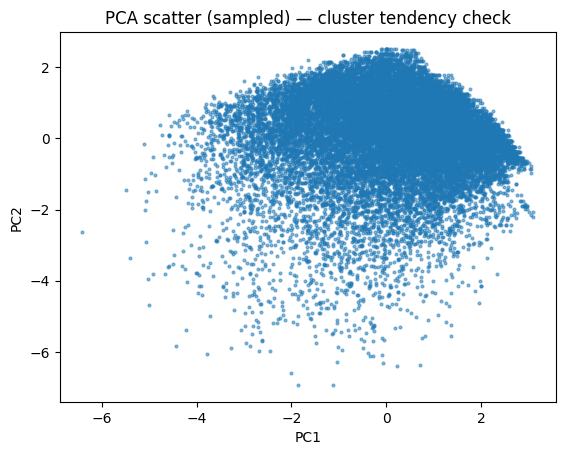

In [ ]:
# CELL 3 — Cluster tendency validation (Hopkins + PCA scatter sample)
# Hopkins statistic helper
def hopkins_statistic(X_use, sample_size=1000, random_state=42):
    """
    H ~ 0.5 => weak/no cluster tendency (random-like)
    H > 0.7 => stronger cluster tendency
    Use on scaled data or PCA space. Here we use PCA space (consistent with clustering).
    """
    rng_local = np.random.default_rng(random_state)
    X_use = np.asarray(X_use)
    n = X_use.shape[0]
    m = min(sample_size, n)

    # Sample real points
    idx = rng_local.choice(n, size=m, replace=False)
    X_m = X_use[idx]

    # Random points in bounding box
    mins = X_use.min(axis=0)
    maxs = X_use.max(axis=0)
    U = rng_local.uniform(mins, maxs, size=(m, X_use.shape[1]))

    # Nearest neighbors for real points (use 2nd NN to avoid self)
    nn2 = NearestNeighbors(n_neighbors=2).fit(X_use)
    d_real, _ = nn2.kneighbors(X_m)
    w = d_real[:, 1]

    # Nearest neighbors for random points
    nn1 = NearestNeighbors(n_neighbors=1).fit(X_use)
    d_unif, _ = nn1.kneighbors(U)
    u = d_unif[:, 0]

    return float(u.sum() / (u.sum() + w.sum()))

# Compute Hopkins statistic in PCA space
H = hopkins_statistic(X_pca, sample_size=1000, random_state=RANDOM_STATE)
print(f"Hopkins statistic (PCA space): {H:.3f}  (≈0.5 weak, >0.7 strong)")

# PCA scatter (sampled for speed)
idx_plot = rng.choice(X_pca.shape[0], size=min(20000, X_pca.shape[0]), replace=False)
plt.figure()
plt.scatter(X_pca[idx_plot, 0], X_pca[idx_plot, 1], s=4, alpha=0.5)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA scatter (sampled) — cluster tendency check")
plt.show()

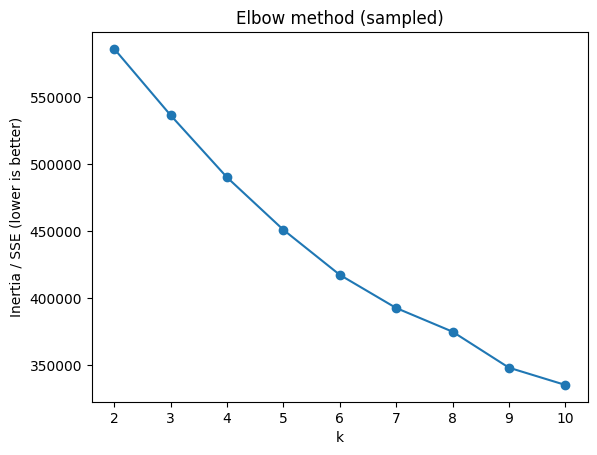

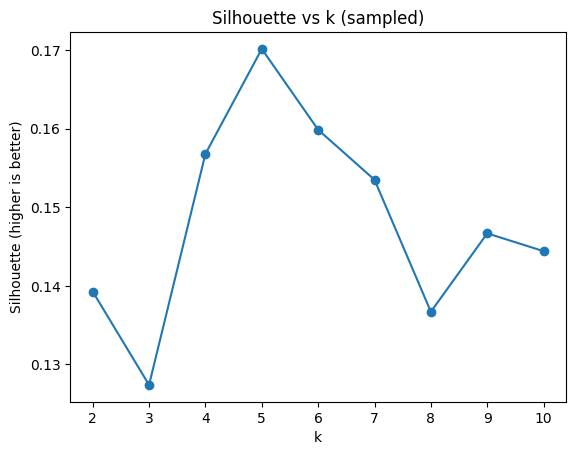

Chosen k (by silhouette on sample): 5


,k,inertia,silhouette
0,2,585934.18750,0.139272
1,3,536440.31250,0.127389
2,4,490149.15625,0.156781
3,5,451067.87500,0.170141
4,6,417518.21875,0.159857
5,7,392805.09375,0.153492
6,8,375158.37500,0.136697
7,9,348335.53125,0.146674
8,10,335464.96875,0.144408


In [ ]:
# CELL 4 — Choose k using Elbow + Silhouette (on a sample for speed)
# Helper to choose k with elbow and silhouette on a sample
def choose_k_elbow_silhouette(X_use, k_min=2, k_max=10, sample_size=50000, random_state=42):
    rng_local = np.random.default_rng(random_state)
    n = X_use.shape[0]
    # Subsample to make repeated KMeans fits feasible
    idx = rng_local.choice(n, size=min(sample_size, n), replace=False)
    X_s = X_use[idx]

    ks = range(k_min, k_max + 1)
    inertias, sils, dbis = [], [], []

    for k in ks:
        # Fit KMeans on the sample
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(X_s)

        # Track inertia and silhouette score
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X_s, labels))

    # Elbow plot
    plt.figure()
    plt.plot(list(ks), inertias, marker="o")
    plt.xlabel("k")
    plt.ylabel("Inertia / SSE (lower is better)")
    plt.title("Elbow method (sampled)")
    plt.show()

    # Silhouette plot
    plt.figure()
    plt.plot(list(ks), sils, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette (higher is better)")
    plt.title("Silhouette vs k (sampled)")
    plt.show()

    results = pd.DataFrame({"k": list(ks), "inertia": inertias, "silhouette": sils})
    best_k = int(results.loc[results["silhouette"].idxmax(), "k"])
    return best_k, results

# Choose k based on silhouette on a sample
best_k, k_table = choose_k_elbow_silhouette(X_pca, k_min=2, k_max=10, sample_size=50000, random_state=RANDOM_STATE)
print("Chosen k (by silhouette on sample):", best_k)
display(k_table)

In [8]:
# CELL 5 — KMEANS: Fit on FULL PCA data + validation metrics
# Fit KMeans on full PCA data
kmeans = KMeans(n_clusters=best_k, n_init=50, random_state=RANDOM_STATE)
labels_km = kmeans.fit_predict(X_pca)
df2["cluster_kmeans"] = labels_km

# Internal validation summary
print("K-Means internal validation:")

# Silhouette on a sample to reduce computation
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(X_pca.shape[0], size=min(30000, X_pca.shape[0]), replace=False)
print("  Silhouette (sampled):", float(silhouette_score(X_pca[idx], labels_km[idx])))

# Cluster sizes
print("\nCluster sizes (K-Means):")
print(pd.Series(labels_km).value_counts().sort_index())

K-Means internal validation:
  Silhouette (sampled): 0.1493472307920456

Cluster sizes (K-Means):
0    87220
1    40978
2    99639
3    12302
4    13541
Name: count, dtype: int64


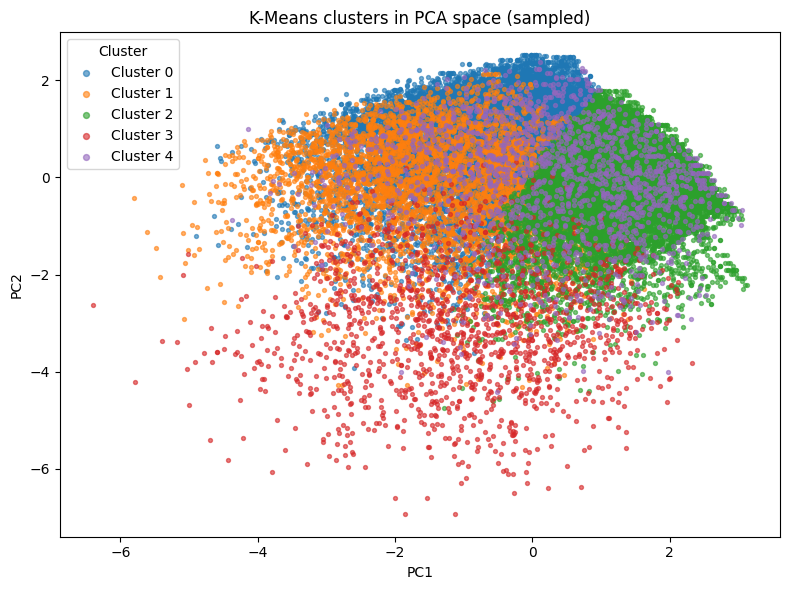

In [ ]:
# PCA scatter with cluster labels in legend
# Sample for plotting clarity
rng = np.random.default_rng(RANDOM_STATE)
idx_plot = rng.choice(X_pca.shape[0], size=min(30000, X_pca.shape[0]), replace=False)

# Prepare sampled points and labels
X_plot = X_pca[idx_plot]
labels_plot = df2["cluster_kmeans"].values[idx_plot]

# Scatter plot by cluster
plt.figure(figsize=(8, 6))
for c in np.unique(labels_plot):
    mask = labels_plot == c
    plt.scatter(
        X_plot[mask, 0],
        X_plot[mask, 1],
        s=8,
        alpha=0.6,
        label=f"Cluster {c}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means clusters in PCA space (sampled)")
plt.legend(title="Cluster", markerscale=1.5)
plt.tight_layout()
plt.show()

## Cluster Interpretation

**Cluster 0 – Older, High Cardiometabolic Risk**  
This cluster is characterised by the highest mean BMI, elevated prevalence of high blood pressure and cholesterol, and the oldest average age. Despite relatively better fruit and vegetable intake, this group exhibits the highest diabetes prevalence (24.0%), suggesting that cumulative metabolic risk and ageing outweigh current dietary behaviour.

**Cluster 1 – Moderate Risk, Poor Diet**  
This cluster shows poorer dietary indicators and moderate metabolic risk. Diabetes prevalence (19.5%) is lower than Cluster 0, likely due to younger age and lower cardiometabolic burden.

**Cluster 2 – Young, Active, Low Risk**  
This cluster represents a young, physically active and socioeconomically advantaged group with the lowest BMI and diabetes prevalence (4.2%).

**Cluster 3 – Socioeconomically Constrained**  
This group is characterised by younger age but reduced healthcare access and higher cost barriers, with intermediate diabetes prevalence (11.5%).

**Cluster 4 – Behavioural Risk Dominant**  
This cluster exhibits high smoking and alcohol consumption but relatively preserved metabolic health, resulting in a comparatively low diabetes prevalence (5.8%).


In [10]:
# Cross-tab of diabetes status within each cluster
pd.crosstab(df2["cluster_kmeans"], df2["Diabetes_012"], normalize="index")

Diabetes_012,0.0,1.0,2.0
cluster_kmeans,,,
0,0.732229,0.027608,0.240163
1,0.781322,0.023476,0.195202
2,0.949638,0.008190,0.042172
3,0.864656,0.020566,0.114778
4,0.927775,0.014179,0.058046


The table above shows the distribution of diabetes status within each cluster. 
Clusters characterised by older age and higher cardiometabolic risk exhibit substantially higher diabetes prevalence, while younger and physically active clusters show the lowest prevalence.


In [ ]:
# AGGLOMERATIVE: Fit on SAMPLE (recommended) + validation metrics
# Agglomerative can be heavy on 250k; use a sample
sample_size_ag = 30000
idx_ag = rng.choice(X_pca.shape[0], size=min(sample_size_ag, X_pca.shape[0]), replace=False)
X_ag = X_pca[idx_ag]

# Fit Agglomerative clustering on the sample
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_ag = agg.fit_predict(X_ag)

# Internal validation on the sample
print(f"Agglomerative internal validation (SAMPLE n={X_ag.shape[0]}, PCA space):")
print("  Silhouette:", float(silhouette_score(X_ag, labels_ag)))

# Cluster sizes for the sample
print("\nCluster sizes (Agglomerative sample):")
print(pd.Series(labels_ag).value_counts().sort_index())

Agglomerative internal validation (SAMPLE n=30000, PCA space):
  Silhouette: 0.16266149282455444

Cluster sizes (Agglomerative sample):
0     2948
1     8892
2     1104
3     1619
4    15437
Name: count, dtype: int64


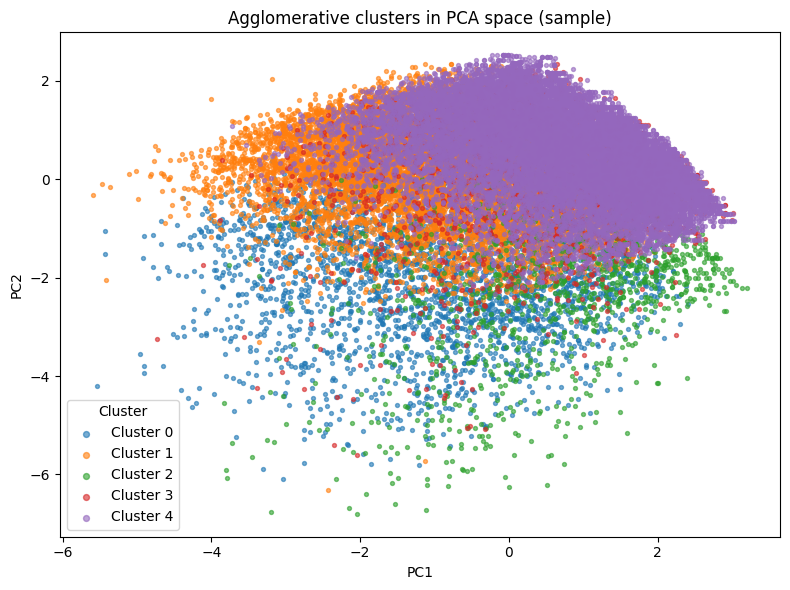

In [ ]:
# AGGLOMERATIVE: Plots (PCA scatter colored + cluster profiles + diabetes prevalence)
# X_ag      -> PCA data used for agglomerative (sample)
# labels_ag -> Agglomerative cluster labels for X_ag

# Scatter plot of agglomerative clusters
plt.figure(figsize=(8, 6))
for c in np.unique(labels_ag):
    mask = labels_ag == c
    plt.scatter(
        X_ag[mask, 0],
        X_ag[mask, 1],
        s=8,
        alpha=0.6,
        label=f"Cluster {c}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative clusters in PCA space (sample)")
plt.legend(title="Cluster", markerscale=1.5)
plt.tight_layout()
plt.show()

### Agglomerative Clustering (Comparison)

Agglomerative clustering (Ward linkage) was applied to a random subsample of the PCA-transformed data due to computational constraints. The resulting clusters exhibit a similar structure to those obtained with K-Means, with comparable separation in PCA space and analogous risk profiles (e.g., older high-risk groups, younger low-risk groups, and behaviour-driven risk segments).

This consistency across clustering algorithms suggests that the identified population segments are robust to the choice of clustering method.


In [ ]:
# Agreement between KMeans and Agglomerative (on the agglomerative sample)
# KMeans labels for the same sampled points
km_on_ag_sample = labels_km[idx_ag]

# Compare label agreement between methods on the shared sample
ct = pd.crosstab(km_on_ag_sample, labels_ag, normalize="index")
print("Contingency table: KMeans (rows) vs Agglomerative (cols), row-normalized")
display(ct)

Contingency table: KMeans (rows) vs Agglomerative (cols), row-normalized


col_0,0,1,2,3,4
row_0,,,,,
0,0.080993,0.317526,0.010773,0.000000,0.590708
1,0.083992,0.885239,0.030769,0.000000,0.000000
2,0.046177,0.113190,0.050089,0.000000,0.790543
3,0.817925,0.001411,0.136203,0.044460,0.000000
4,0.000000,0.000000,0.038319,0.961681,0.000000


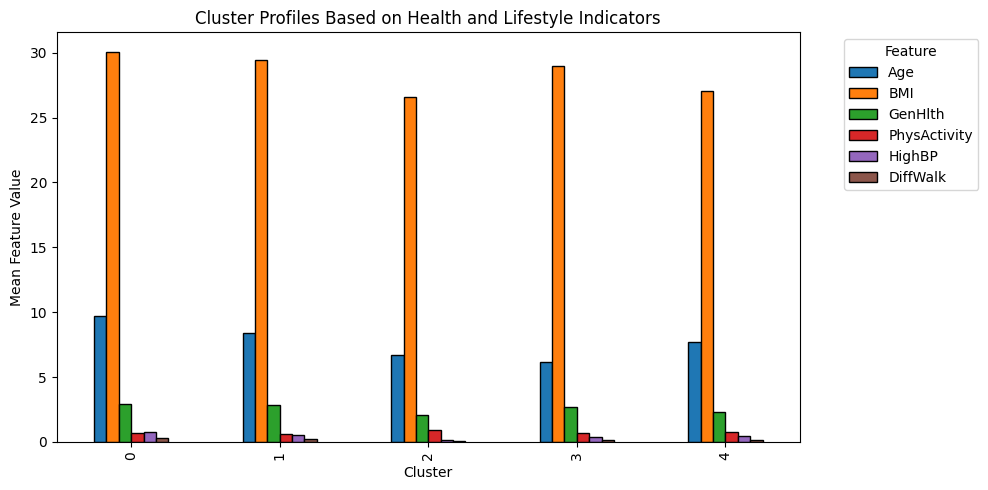

In [ ]:
# Cluster profiles using original features
# Select features to summarize by cluster
features = ["Age", "BMI", "GenHlth", "PhysActivity", "HighBP", "DiffWalk"]

# Build a profile table with cluster labels
df_profiles = df2[features].copy()
df_profiles["Cluster"] = df2["cluster_kmeans"]

# Compute mean feature values by cluster
cluster_means = df_profiles.groupby("Cluster").mean()

# Plot cluster profiles
cluster_means.plot(
    kind="bar",
    figsize=(10, 5),
    edgecolor="black"
 )

plt.ylabel("Mean Feature Value")
plt.xlabel("Cluster")
plt.title("Cluster Profiles Based on Health and Lifestyle Indicators")
plt.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

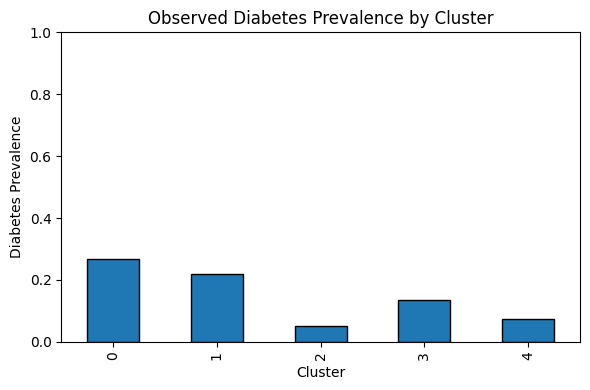

In [ ]:
# Observed diabetes prevalence by KMeans cluster
# Select cluster labels and target column
cluster_col = "cluster_kmeans"
target_col = "Diabetes_012" if "Diabetes_012" in df2.columns else TARGET_COL

# Build a binary indicator for diabetes status
df_prev = df2[[cluster_col, target_col]].copy()
df_prev["Diabetes"] = (df_prev[target_col] > 0).astype(int)

# Compute prevalence by cluster
prevalence = df_prev.groupby(cluster_col)["Diabetes"].mean()

# Plot prevalence by cluster
prevalence.plot(
    kind="bar",
    figsize=(6, 4),
    edgecolor="black"
 )

plt.ylabel("Diabetes Prevalence")
plt.xlabel("Cluster")
plt.title("Observed Diabetes Prevalence by Cluster")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()